## Data setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/data/my_dataset/images/"
csv_path = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/data/my_dataset/labels/labels_claradataset.csv"

In [ ]:
import os
import pandas as pd
from datasets import Dataset, Features, Image, ClassLabel

# 1. Load the CSV
# Added sep=',' as per your update, and keeping header=None for the file provided
df = pd.read_csv(csv_path, sep=',', header=None, names=['filename', 'label'])

# 2. Prepare the data dictionary with full paths
# Ensure extensions are handled if the CSV only contains IDs (e.g., adding '.jpg' if needed)
data_dict = {
    "image": [os.path.join(images_path, f"{fname}.JPG") if "." not in str(fname) else os.path.join(images_path, str(fname)) for fname in df['filename']],
    "label": df['label'].tolist()
}

# 3. Define the Features
features = Features({
    "image": Image(),
    "label": ClassLabel(num_classes=2, names=["NonHuman", "Human"])
})

# 4. Create the Dataset object
custom_dataset = Dataset.from_dict(data_dict, features=features)

# 5. Split for training, testing, and validation
# First, split into 70% train and 30% for temp
train_test_val_split = custom_dataset.train_test_split(test_size=0.30, shuffle=True, seed=42)
train_dataset = train_test_val_split['train']
temp_dataset = train_test_val_split['test'] # This is 30% of the original dataset

# Then, split the temp_dataset into 15% test and 15% validation (50/50 split of the 30% temp_dataset)
test_val_split = temp_dataset.train_test_split(test_size=0.5, shuffle=True, seed=42)
test_dataset = test_val_split['train'] # This is 15% of the original dataset
validation_dataset = test_val_split['test'] # This is 15% of the original dataset

# Combine into a single DatasetDict
from datasets import DatasetDict
dataset = DatasetDict({
    'train': train_dataset,
    'test': test_dataset,
    'validation': validation_dataset
})

print("Custom dataset successfully loaded and shuffled!")
print(dataset)

Custom dataset successfully loaded and shuffled!
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 933
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 200
    })
})


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

# YOLOv8 models typically expect 224x224 for classification
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def collate_fn(batch):
    images = []
    labels = []
    for item in batch:
        img = item['image'].convert("RGB")
        images.append(transform(img))
        labels.append(item['label'])
    return torch.stack(images), torch.tensor(labels)

train_loader = DataLoader(dataset['train'], batch_size=16, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(dataset['test'], batch_size=16, shuffle=False, collate_fn=collate_fn)
validation_loader = DataLoader(dataset['validation'], batch_size=16, shuffle=False, collate_fn=collate_fn)

In [ ]:
print(f"Training samples: {len(dataset['train'])}")
print(f"Training batches: {len(train_loader)}")
print(f"Test samples: {len(dataset['test'])}")
print(f"Test batches: {len(test_loader)}")
print(f"Validation samples: {len(dataset['validation'])}")
print(f"Validation batches: {len(validation_loader)}")

Training samples: 933
Training batches: 59
Test samples: 200
Test batches: 13
Validation samples: 200
Validation batches: 13


## Model setup

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch.nn as nn

model = YOLO("yolov8m.pt")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
print("--- Model Architecture ---")
print(model)

print("\n--- Model Summary ---")
model.info()

--- Model Architecture ---
YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, 

(169, 25902640, 0, 79.3204224)

In [ ]:
# Freeze the backbone layers for transfer learning
for i in range(10):
  layer = model.model.model[i]
  layer.eval()
  for param in layer.parameters():
    param.requires_grad = False

print("Backbone frozen. Model ready for transfer learning.")

Backbone frozen. Model ready for transfer learning.


In [ ]:
from ultralytics import YOLO
import torch.nn as nn
import torch

backbone = model.model.model[:10]
num_classes = 2

# YOLO outputs 576 channels
classifier = nn.Sequential(
    backbone,
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(576, num_classes)
)

print("Custom classifier built successfully using YOLOv8 backbone.")
print(classifier)

Custom classifier built successfully using YOLOv8 backbone.
Sequential(
  (0): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats

## Training

In [ ]:
from sklearn.metrics import f1_score
import torch
import torch.nn as nn
from tqdm import tqdm

def train_model(classifier, train_loader, validation_loader, criterion, optimizer, epochs, device):
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    train_f1_scores = []
    val_f1_scores = []

    print(f"Using device: {device}")

    for epoch in range(epochs):
        classifier.train()
        running_train_loss = 0.0
        all_train_preds = [] # To store predictions for training metrics
        all_train_labels = [] # To store labels for training metrics

        # Training Phase
        for imgs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = classifier(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

            # Collect predictions and labels for training metrics
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(labels.cpu().numpy())

        # Calculate Training Metrics
        train_loss = running_train_loss / len(train_loader)
        train_correct = sum([1 for p, l in zip(all_train_preds, all_train_labels) if p == l])
        train_accuracy = 100 * train_correct / len(all_train_labels)
        train_f1 = f1_score(all_train_labels, all_train_preds, average='binary')

        # Store training results
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        train_f1_scores.append(train_f1)

        # Validation Phase
        classifier.eval()
        running_val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for imgs, labels in tqdm(validation_loader, desc=f"Epoch {epoch+1}/{epochs} [Validation]"):
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = classifier(imgs)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

                _, predicted = torch.max(outputs.data, 1)
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate Validation Metrics
        val_loss = running_val_loss / len(validation_loader)

        correct = sum([1 for p, l in zip(all_preds, all_labels) if p == l])
        accuracy = 100 * correct / len(all_labels)
        f1 = f1_score(all_labels, all_preds, average='binary')

        # Store validation results
        val_losses.append(val_loss)
        val_accuracies.append(accuracy)
        val_f1_scores.append(f1)

        print(f"\nEpoch {epoch+1} Results:")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_accuracy:.2f}% | Train F1 Score: {train_f1:.4f}")
        print(f"Validation Loss: {val_loss:.4f} | Validation Acc: {accuracy:.2f}% | Validation F1 Score: {f1:.4f}\n")

    print("Transfer Learning Complete!")
    return train_losses, val_losses, train_accuracies, val_accuracies, train_f1_scores, val_f1_scores

# Initialize training components
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, classifier.parameters()), lr=1e-3)
epochs = 5
classifier.to(device)

# Call the new train_model function and unpack all returned values
train_losses, val_losses, train_accuracies, val_accuracies, train_f1_scores, val_f1_scores = train_model(
    classifier, train_loader, validation_loader, criterion, optimizer, epochs, device
)

print("\n--- Training Summary ---")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Train F1 Score: {train_f1_scores[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Final Validation F1 Score: {val_f1_scores[-1]:.4f}")

Using device: cuda


Epoch 1/5 [Validation]: 100%|██████████| 13/13 [02:58<00:00, 13.70s/it]



Epoch 1 Results:
Train Loss: 0.5443 | Train Acc: 71.81% | Train F1 Score: 0.8349
Validation Loss: 0.4522 | Validation Acc: 76.00% | Validation F1 Score: 0.8636



Epoch 2/5 [Validation]: 100%|██████████| 13/13 [00:01<00:00,  8.23it/s]



Epoch 2 Results:
Train Loss: 0.4600 | Train Acc: 75.78% | Train F1 Score: 0.8564
Validation Loss: 0.3801 | Validation Acc: 81.00% | Validation F1 Score: 0.8862



...


Epoch 3 Results:
Train Loss: 0.4162 | Train Acc: 79.53% | Train F1 Score: 0.8712
Validation Loss: 0.3499 | Validation Acc: 89.00% | Validation F1 Score: 0.9281



Epoch 4/5 [Validation]: 100%|██████████| 13/13 [00:01<00:00,  8.34it/s]



Epoch 4 Results:
Train Loss: 0.3821 | Train Acc: 81.89% | Train F1 Score: 0.8851
Validation Loss: 0.3106 | Validation Acc: 89.00% | Validation F1 Score: 0.9299



Epoch 5/5 [Validation]: 100%|██████████| 13/13 [00:01<00:00,  8.65it/s]


Epoch 5 Results:
Train Loss: 0.3496 | Train Acc: 86.17% | Train F1 Score: 0.9096
Validation Loss: 0.2931 | Validation Acc: 91.00% | Validation F1 Score: 0.9423

Transfer Learning Complete!

--- Training Summary ---
Final Train Loss: 0.3496
Final Train Accuracy: 86.17%
Final Train F1 Score: 0.9096
Final Validation Loss: 0.2931
Final Validation Accuracy: 91.00%
Final Validation F1 Score: 0.9423


In [ ]:
import os
import torch

save_directory = "/content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/results/yolo_classifier"

os.makedirs(save_directory, exist_ok=True)

save_path = os.path.join(save_directory, "yolo_classifier_new.pkt")

torch.save(classifier, save_path)

print(f"Model successfully saved to: {save_path}")

Model successfully saved to: /content/drive/MyDrive/deep learning/UPF_Deep_Learning_2026/Final Project/results/yolo_classifier/yolo_classifier_new.pkt


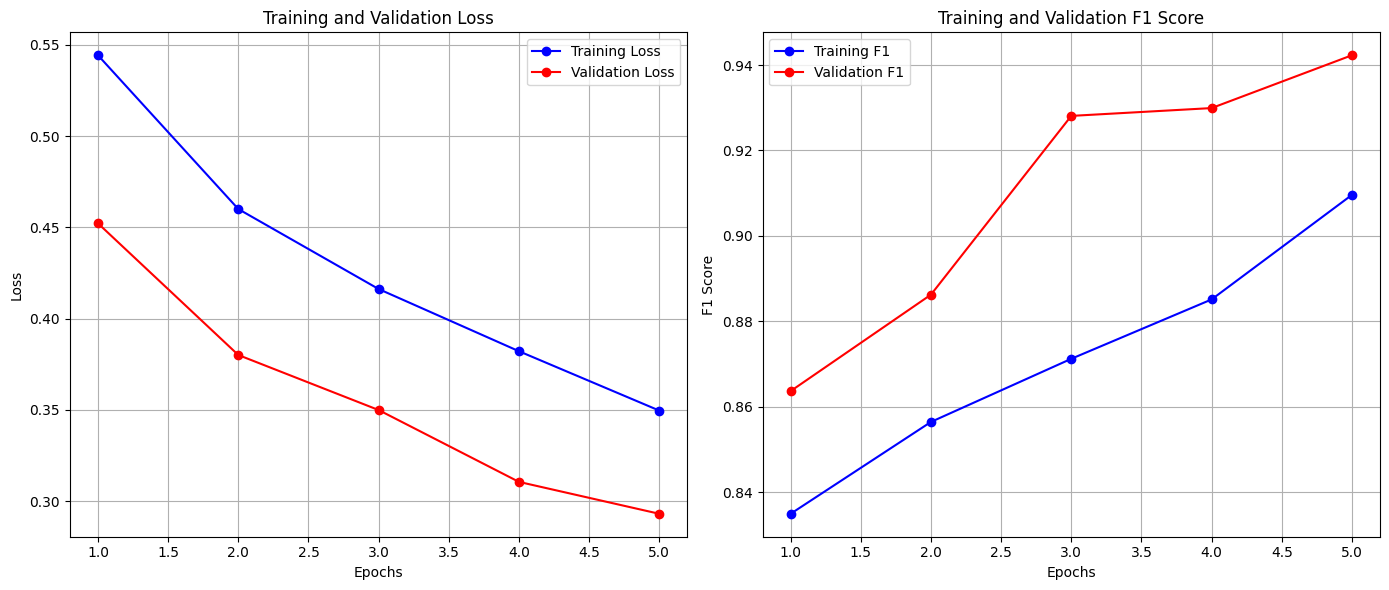

In [ ]:
import matplotlib.pyplot as plt

# Create a range for the epochs to use as the x-axis for plotting
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(14, 6)) # Adjusted figure size for 2 plots

# Plot Loss Curves
plt.subplot(1, 2, 1) # Changed to 1 row, 2 columns, first plot
plt.plot(epochs_range, train_losses, 'b-o', label='Training Loss')
plt.plot(epochs_range, val_losses, 'r-o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot F1 Score Curves
plt.subplot(1, 2, 2) # Changed to 1 row, 2 columns, second plot
plt.plot(epochs_range, train_f1_scores, 'b-o', label='Training F1')
plt.plot(epochs_range, val_f1_scores, 'r-o', label='Validation F1')
plt.title('Training and Validation F1 Score')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Evaluation on test

In [ ]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

def evaluate_model(classifier, data_loader, device):
    classifier.eval() # Set the model to evaluation mode
    all_preds = []
    all_labels = []

    with torch.no_grad(): # Disable gradient calculation during evaluation
        for imgs, labels in tqdm(data_loader, desc="Evaluating on Test Set"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = classifier(imgs)
            _, predicted = torch.max(outputs.data, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='binary') # Assuming binary classification

    print(f"\nTest Accuracy: {accuracy:.4f}")
    print(f"Test F1 Score: {f1:.4f}")

    return accuracy, f1, all_labels, all_preds # Added all_labels and all_preds to the return

# Initialize device (should be the same as during training)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Perform evaluation
test_accuracy, test_f1_score, test_true_labels, test_predictions = evaluate_model(classifier, test_loader, device)

Evaluating on Test Set: 100%|██████████| 13/13 [02:58<00:00, 13.72s/it]


Test Accuracy: 0.8850
Test F1 Score: 0.9231


Evaluating on Test Set: 100%|██████████| 13/13 [00:01<00:00,  8.72it/s]



Test Accuracy: 0.8850
Test F1 Score: 0.9231
Model evaluation re-executed and labels/predictions retrieved.


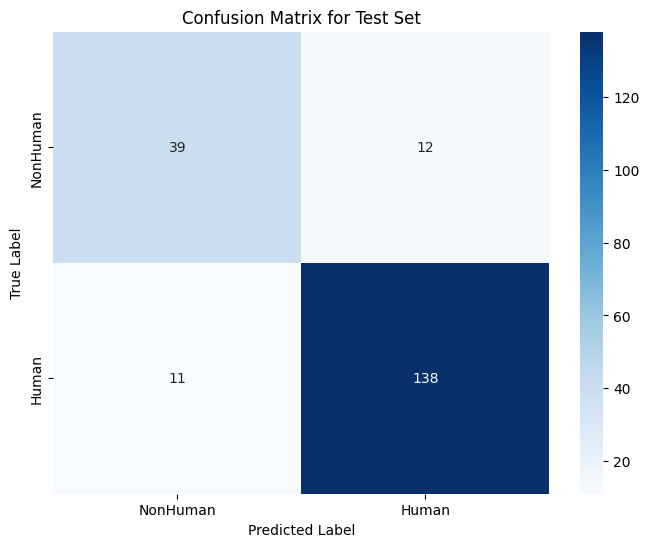

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import torch

# Ensure that the evaluate_model function and its dependencies (classifier, test_loader, device) are available.
# If this cell is run independently or if the previous evaluation was interrupted,
# test_true_labels and test_predictions might not be defined.

test_accuracy, test_f1_score, test_true_labels, test_predictions = evaluate_model(classifier, test_loader, device)
print("Model evaluation re-executed and labels/predictions retrieved.")


# Compute the confusion matrix
cm = confusion_matrix(test_true_labels, test_predictions)

# Define class labels for better readability
class_names = ['NonHuman', 'Human'] # Assuming 0 for NonHuman and 1 for Human based on dataset setup

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Test Set')
plt.show()

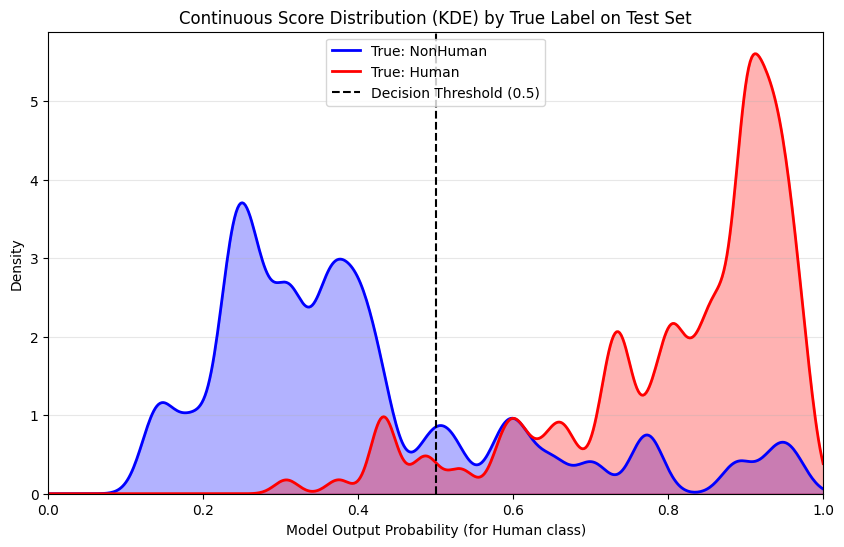

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F # Import functional for softmax
import numpy as np
from scipy.stats import gaussian_kde

def plot_score_distribution_continuous(model, loader, device):
    model.eval()
    scores_pos = [] # Scores for true positive class (Human)
    scores_neg = [] # Scores for true negative class (NonHuman)

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)

            # Apply softmax to get probabilities for each class
            # For binary classification, we are interested in the probability of the positive class (index 1)
            probabilities = F.softmax(outputs, dim=1)[:, 1].cpu().numpy().flatten()
            labels = labels.cpu().numpy().flatten()

            for score, label in zip(probabilities, labels):
                if label == 1: # True Human
                    scores_pos.append(score)
                else: # True NonHuman
                    scores_neg.append(score)

    plt.figure(figsize=(10, 6))
    x_range = np.linspace(0, 1, 500)

    # Generate KDE for 'No Person' (True label 0)
    if len(scores_neg) > 1:
        kde_neg = gaussian_kde(scores_neg, bw_method=0.1)
        y_neg = kde_neg(x_range)
        plt.plot(x_range, y_neg, color='blue', lw=2, label='True: NonHuman')
        plt.fill_between(x_range, 0, y_neg, color='blue', alpha=0.3)

    # Generate KDE for 'Person' (True label 1)
    if len(scores_pos) > 1:
        kde_pos = gaussian_kde(scores_pos, bw_method=0.1)
        y_pos = kde_pos(x_range)
        plt.plot(x_range, y_pos, color='red', lw=2, label='True: Human')
        plt.fill_between(x_range, 0, y_pos, color='red', alpha=0.3)

    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Threshold (0.5)')
    plt.xlabel('Model Output Probability (for Human class)')
    plt.ylabel('Density')
    plt.title('Continuous Score Distribution (KDE) by True Label on Test Set')
    plt.legend(loc='upper center')
    plt.grid(axis='y', alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(bottom=0)
    plt.show()

# Plot the distribution using the trained classifier and test_loader
plot_score_distribution_continuous(classifier, test_loader, device)